Imports

In [12]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

Cargar datasets

In [13]:
DATA_PATH = Path("../../data/features/hotel_ttoo")
files = list(DATA_PATH.glob("*.parquet"))
hotel_datasets = {}
for file in files:
    hotel_name = file.stem          
    df = pd.read_parquet(file)
    df["fecha"] = pd.to_datetime(df["fecha"])
    df = df.sort_values("fecha").set_index("fecha")
    df = df.asfreq("D")
    hotel_datasets[hotel_name] = df

Split temporal

In [14]:
splits = {}
CUTOFF = pd.Timestamp("2025-01-01")
for hotel, df in hotel_datasets.items():
    ts    = df["ocup_total"].asfreq("D")
    train = ts[ts.index < CUTOFF]
    test  = ts[ts.index >= CUTOFF]
    splits[hotel] = (train, test)

Test de estacionariedad

In [15]:
def adf_test(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:",       result[1])

for hotel, (train, test) in splits.items():
    print(f"\nADF Test - {hotel}")
    adf_test(train)


ADF Test - HOTEL_1
ADF Statistic: -4.545134633586577
p-value: 0.0001628339806294615

ADF Test - HOTEL_2
ADF Statistic: -2.6330963681073256
p-value: 0.08634800732937148

ADF Test - HOTEL_3
ADF Statistic: -2.38612553215479
p-value: 0.14569072714500575


Entrenamiento ARIMA ARIMA(1,1,1)

In [16]:
def compute_metrics(y_true_s, y_pred_s, eps=1e-8):
    y_pred_s = y_pred_s.reindex(y_true_s.index)
    y_true   = y_true_s.to_numpy(dtype=float)
    y_pred   = y_pred_s.to_numpy(dtype=float)
    mask     = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true   = y_true[mask]; y_pred = y_pred[mask]
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    mape  = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0
    return float(mae), float(rmse), float(mape)

In [17]:
results   = []
pred_list = []
for hotel, (train, test) in splits.items():
    res  = ARIMA(train, order=(1, 1, 1)).fit()
    fc   = res.get_forecast(steps=len(test))
    pred = fc.predicted_mean.reindex(test.index)

    mae, rmse, mape = compute_metrics(test, pred)
    results.append({
        "hotel":  hotel,
        "modelo": "ARIMA",
        "MAE":    mae,
        "RMSE":   rmse,
        "MAPE":   mape
    })
    pred_list.append(pd.DataFrame({
        "fecha":  test.index,
        "hotel":  hotel,
        "modelo": "ARIMA",
        "y_real": test.values,
        "y_pred": pred.values
    }))

arima_results = pd.DataFrame(results).sort_values("hotel")
arima_results

c:\Users\jorge gonzalez\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\jorge gonzalez\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\jorge gonzalez\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,hotel,modelo,MAE,RMSE,MAPE
0,HOTEL_1,ARIMA,0.118347,0.143329,30.029578
1,HOTEL_2,ARIMA,0.167308,0.221576,31.986218
2,HOTEL_3,ARIMA,0.095105,0.125474,18.078647


Visualización

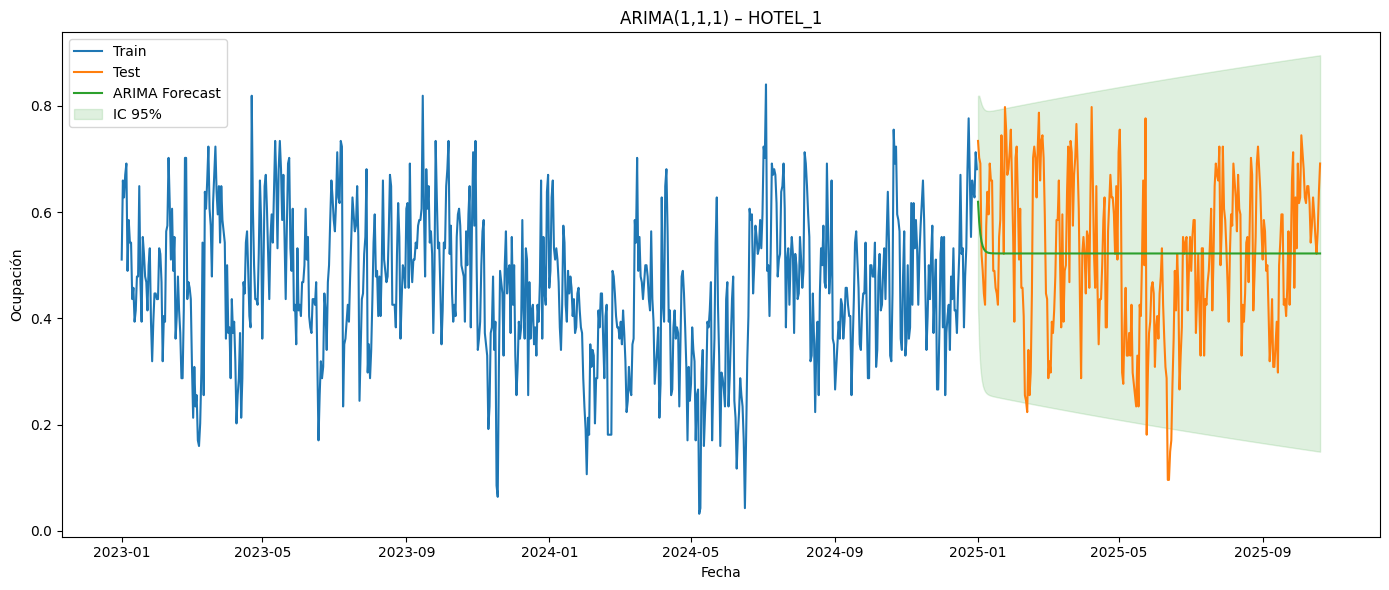

c:\Users\jorge gonzalez\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


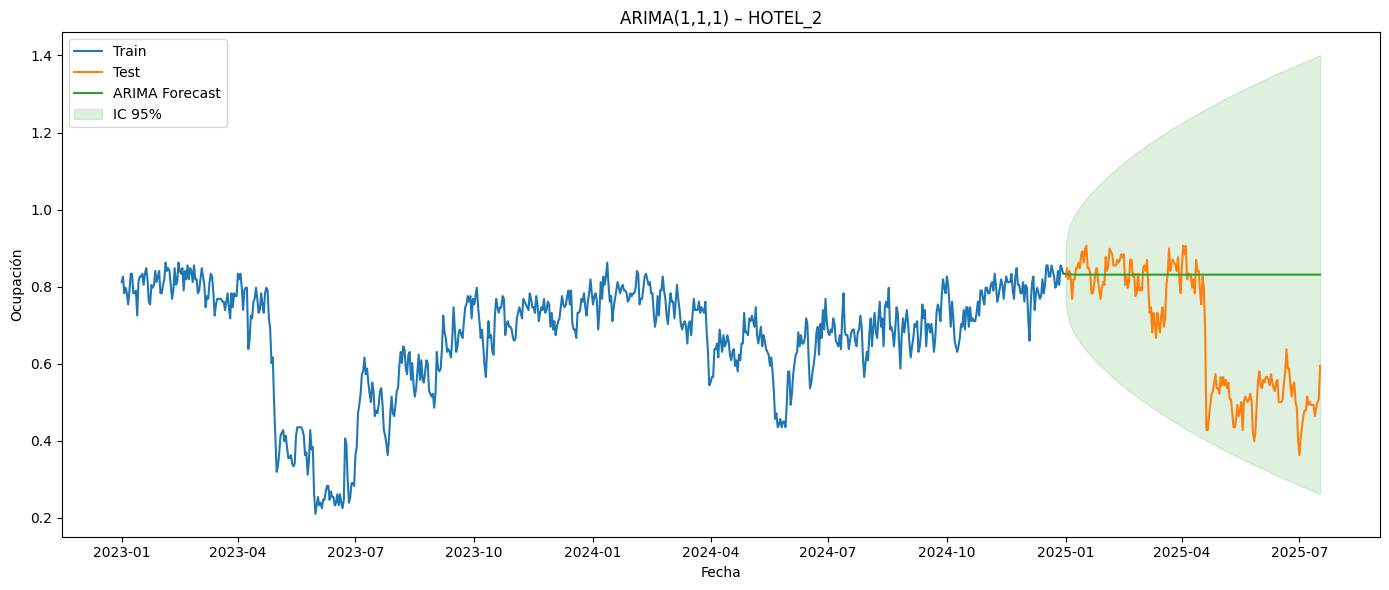

c:\Users\jorge gonzalez\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\jorge gonzalez\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


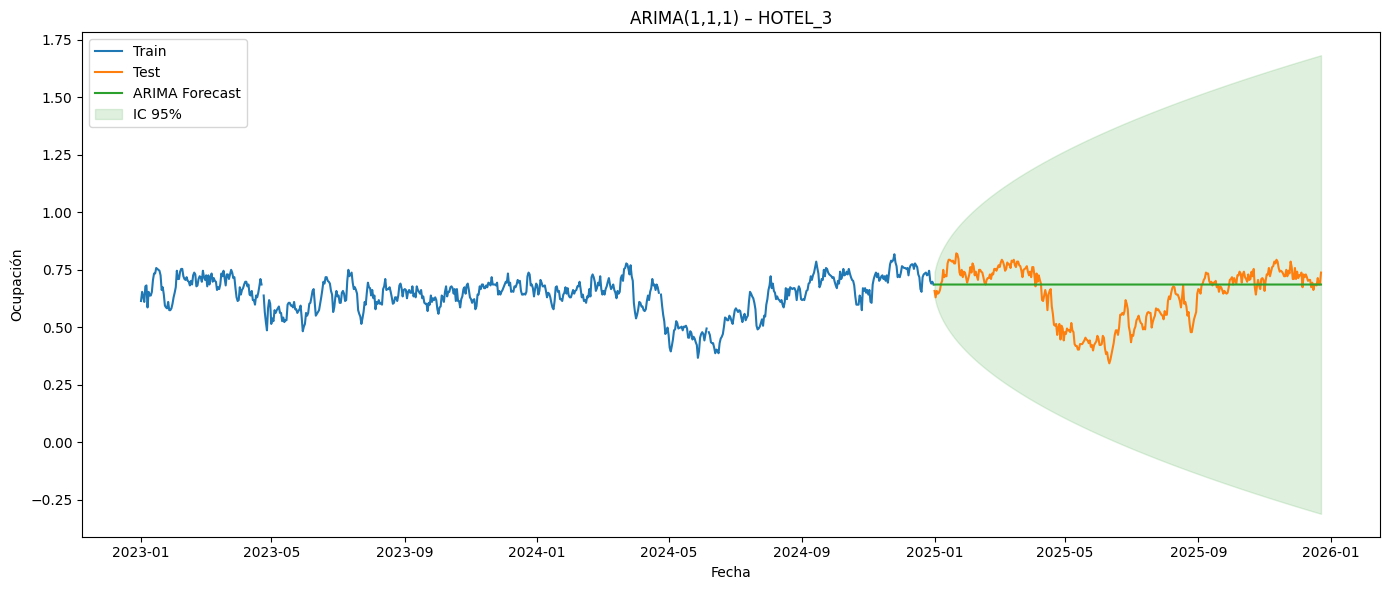

In [18]:
for hotel, (train, test) in splits.items():
    res  = ARIMA(train, order=(1, 1, 1)).fit()
    fc   = res.get_forecast(steps=len(test))
    pred = fc.predicted_mean
    ci   = fc.conf_int(alpha=0.05)

    plt.figure(figsize=(14, 6))
    plt.plot(train.index, train,  label="Train",           color="C0")
    plt.plot(test.index,  test,   label="Test",            color="C1")
    plt.plot(test.index,  pred,   label="ARIMA Forecast",  color="C2")
    plt.fill_between(test.index, ci.iloc[:, 0], ci.iloc[:, 1],
                     color="C2", alpha=0.15, label="IC 95%")
    plt.title(f"ARIMA(1,1,1) – {hotel}")
    plt.xlabel("Fecha")
    plt.ylabel("Ocupación")
    plt.legend()
    plt.tight_layout()
    plt.show()

Métricas

In [19]:
METRICS_PATH = Path("../../models/metrics")
METRICS_PATH.mkdir(parents=True, exist_ok=True)
arima_results.to_csv(METRICS_PATH / "arima_results.csv", index=False)
print("Métricas guardadas en:", METRICS_PATH / "arima_results.csv")

Métricas guardadas en: ..\..\models\metrics\arima_results.csv


Predicciones

In [20]:
PRED_PATH = Path("../../models/predictions")
PRED_PATH.mkdir(parents=True, exist_ok=True)

pred_list = []
for hotel, (train, test) in splits.items():
    model = ARIMA(train, order=(1, 1, 1)).fit()
    fc    = model.get_forecast(steps=len(test))
    pred  = fc.predicted_mean
    if not pred.index.equals(test.index):
        pred = pred.reindex(test.index)

    pred_list.append(pd.DataFrame({
        "fecha":  test.index,
        "hotel":  hotel,
        "modelo": "ARIMA",
        "y_real": test.values,
        "y_pred": pred.values
    }))

df_pred_arima = pd.concat(pred_list, ignore_index=True)
out_file = PRED_PATH / "arima_predictions.parquet"
df_pred_arima.to_parquet(out_file, index=False)
print("✅ Predicciones ARIMA guardadas en:", out_file)
df_pred_arima.head()

c:\Users\jorge gonzalez\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\jorge gonzalez\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\jorge gonzalez\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


✅ Predicciones ARIMA guardadas en: ..\..\models\predictions\arima_predictions.parquet


,fecha,hotel,modelo,y_real,y_pred
0,2025-01-01,HOTEL_1,ARIMA,0.734043,0.619440
1,2025-01-02,HOTEL_1,ARIMA,0.702128,0.581788
2,2025-01-03,HOTEL_1,ARIMA,0.691489,0.558703
3,2025-01-04,HOTEL_1,ARIMA,0.521277,0.544549
4,2025-01-05,HOTEL_1,ARIMA,0.489362,0.535872


Importancia / Influencia en ARIMA

In [21]:
adf_summary = []
for hotel, (train, _) in splits.items():
    stat, pval, *_ = adfuller(train.dropna())
    adf_summary.append({"hotel": hotel, "ADF_stat": stat, "p_value": pval})

adf_df = pd.DataFrame(adf_summary).sort_values("hotel")
adf_df

,hotel,ADF_stat,p_value
0,HOTEL_1,-4.545135,0.000163
1,HOTEL_2,-2.633096,0.086348
2,HOTEL_3,-2.386126,0.145691


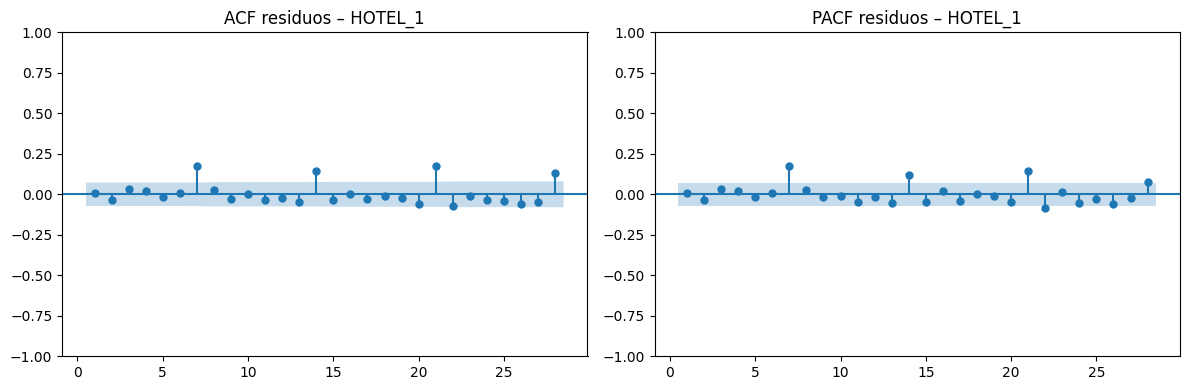

c:\Users\jorge gonzalez\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


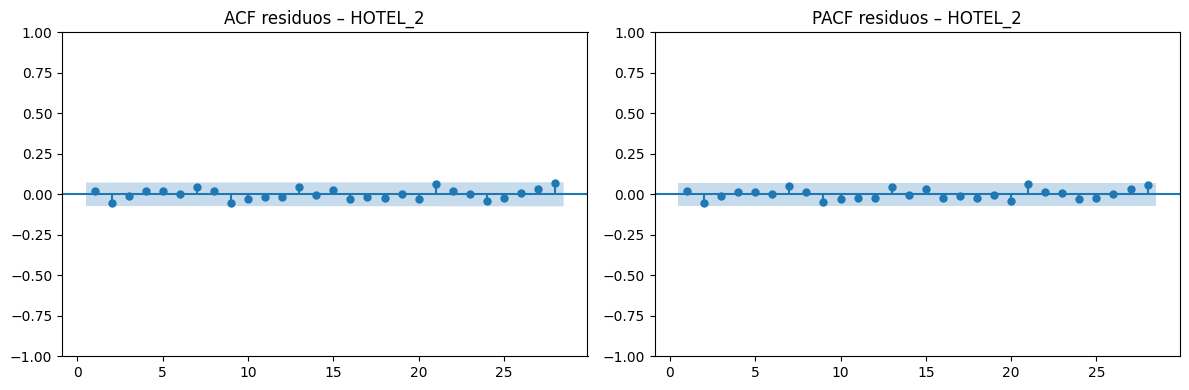

c:\Users\jorge gonzalez\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\jorge gonzalez\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


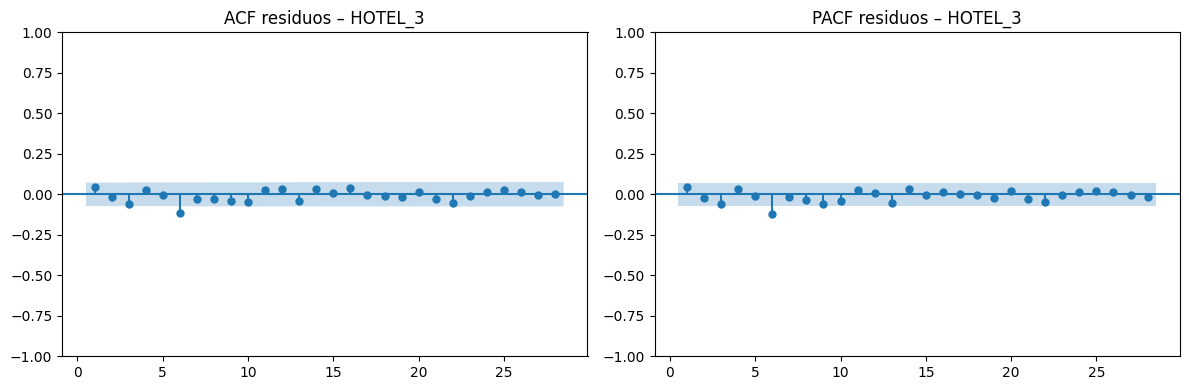

In [22]:
for hotel, (train, test) in splits.items():
    res   = ARIMA(train, order=(1, 1, 1)).fit()
    resid = res.resid

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf( resid.dropna(), lags=28, zero=False, ax=ax[0])
    plot_pacf(resid.dropna(), lags=28, zero=False, ax=ax[1])
    ax[0].set_title(f"ACF residuos – {hotel}")
    ax[1].set_title(f"PACF residuos – {hotel}")
    plt.tight_layout()
    plt.show()

# Conclusiones — Modelo ARIMA(1,1,1)

## Objetivo

Evaluar hasta qué punto la ocupación hotelera diaria puede predecirse únicamente
con su propio histórico (sin variables externas), usando un ARIMA(1,1,1) por hotel.
Esta sección establece una referencia clásica frente a modelos con estacionalidad
(SARIMA) y con exógenas (SARIMAX / ML).

---

## Diagnóstico de estacionariedad (ADF) — Entrenamiento

Resultados del test ADF sobre la **serie de entrenamiento** (fechas anteriores a 2025‑01‑01):

- **Hotel 1:** ADF = −4.55, *p* = 0.00016 → Estacionaria.
- **Hotel 2:** ADF = −2.63, *p* = 0.08635 → No estacionaria.
- **Hotel 3:** ADF = −2.39, *p* = 0.14569 → No estacionaria.

**Lectura:**
En Hotel 2 y Hotel 3 es necesaria la diferenciación (*d = 1*), lo que refleja
cambios de nivel o tendencia en el tiempo. En Hotel 1, la serie ya es estacionaria;
aun así, entrenar con *d = 1* no invalida el modelo, aunque puede inducir un
suavizado excesivo.

---

## Resultados en test (cutoff temporal fijo)

El modelo se evalúa bajo un criterio temporal homogéneo para todos los hoteles:

- **Entrenamiento:** fechas < 2025‑01‑01
- **Test:** fechas ≥ 2025‑01‑01 hasta el último histórico disponible

Bajo este esquema, los resultados muestran que:

- Los errores de ARIMA(1,1,1) son sensiblemente superiores a los baselines simples (Naive, MA(7)).
- El modelo tiende a suavizar la serie y no replica bien picos ni caídas abruptas.
- Esta debilidad es especialmente visible en hoteles con alta variabilidad diaria
  y estacionalidad marcada (Hotel 2 y Hotel 3).

---

## Comportamiento visual del forecast

- En los tres hoteles, las predicciones se manifiestan como una curva suavizada.
- El modelo no reacciona con rapidez ante cambios bruscos de ocupación.
- En Hotel 2 y Hotel 3, la ausencia de estacionalidad explícita limita claramente
  la capacidad predictiva.
- En Hotel 1, pese a tratarse de una serie estacionaria, ARIMA(1,1,1) no captura
  la dinámica de corto plazo con la precisión observada en medias móviles simples.

---

## "Importancia / Influencia" en ARIMA

ARIMA no utiliza variables exógenas (touroperadores, tarifas, calendario…), por lo
que no existen pesos o importancias por variable como en Random Forest o XGBoost.
La interpretación se basa en la **estructura temporal interna** de la serie:

1. **Estacionariedad (ADF)**
   Los valores elevados de *p* en Hotel 2 y Hotel 3 evidencian la necesidad de
   diferenciación, reflejando cambios de nivel que influyen en la predicción.

2. **Patrones en residuos (ACF / PACF)**
   Los correlogramas no muestran picos extremadamente dominantes, pero sí indican
   variabilidad no explicada. La posible presencia de patrones semanales refuerza
   la conveniencia de modelos estacionales (SARIMA).

3. **Efecto práctico observado**
   El suavizado excesivo del forecast indica que la dependencia diaria y semanal
   real de la ocupación no puede capturarse únicamente con un ARIMA(1,1,1).

En este contexto, la "influencia" dominante que explota el modelo es tendencial,
pero insuficiente para reproducir la estructura temporal completa de la demanda hotelera.

---

## Conclusión global

El modelo **ARIMA(1,1,1)** confirma que el histórico de ocupación, por sí solo,
resulta insuficiente para modelar de forma realista la ocupación hotelera diaria:

- En **Hotel 1**, no reproduce correctamente la variabilidad diaria.
- En **Hotel 2 y Hotel 3**, ignora la estacionalidad fuerte y la persistencia
  real de la demanda.

La adopción de un **cutoff temporal fijo** refuerza esta conclusión al garantizar
comparabilidad directa con el resto de modelos. Los resultados justifican avanzar hacia:

- **SARIMA**, incorporando estacionalidad explícita.
- **SARIMAX y modelos de aprendizaje automático**, donde las variables exógenas
  de negocio permiten capturar la estructura operativa real y medir de forma
  directa el impacto de cada factor.